In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv("../data/cleaned/customer_churn_cleaned.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [5]:
#How many customers have chruned
df['Churn'].value_counts()

No     5163
Yes    1869
Name: Churn, dtype: int64

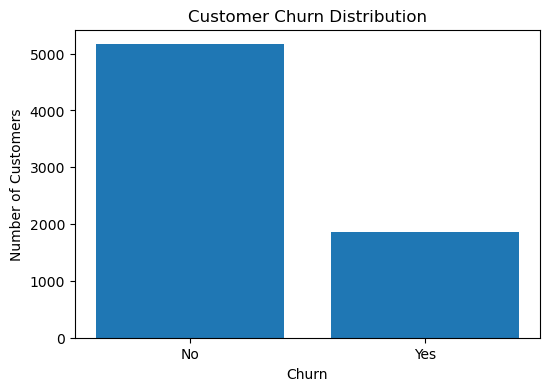

In [8]:
churn = df['Churn'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn.index, churn.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
#Most customers are retained, but a significant percentage have churned. Understanding these customers is important for improving retention.

In [10]:
#What is the Churn Rate?
churn_rate = (df['Churn'].value_counts(normalize=True)*100)
print(churn_rate)

No     73.421502
Yes    26.578498
Name: Churn, dtype: float64


In [11]:
#Does Gender Affect Churn?
pd.crosstab(df['gender'],df['Churn'])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


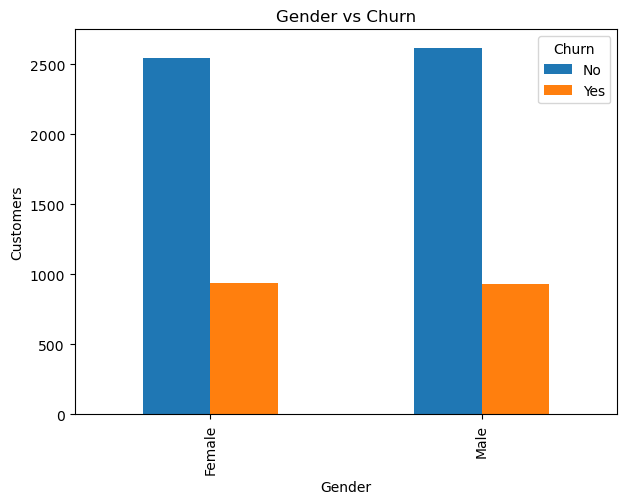

In [12]:
gender = pd.crosstab(df['gender'], df['Churn'])

gender.plot(kind='bar', figsize=(7,5))

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Customers")

plt.show()

In [13]:
#Compare the churn rates for males and females. If they are similar, gender may not be a strong factor.

In [15]:
#Which Contract Type Has the Highest Churn
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


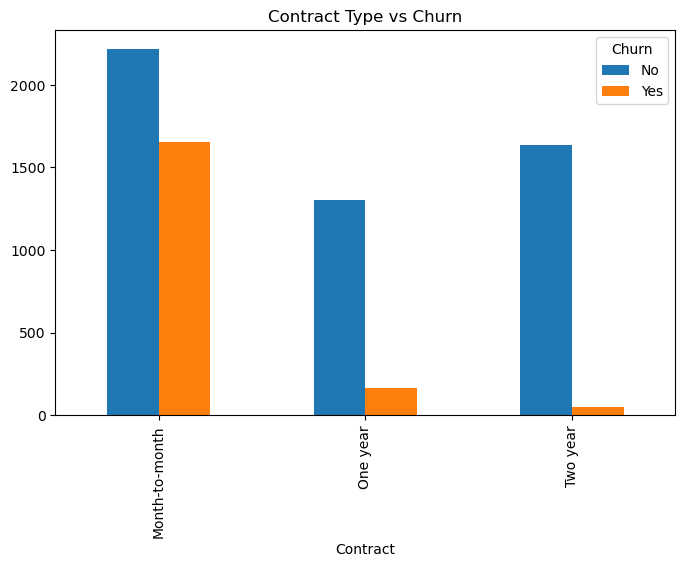

In [16]:
contract = pd.crosstab(df['Contract'], df['Churn'])

contract.plot(kind='bar', figsize=(8,5))

plt.title("Contract Type vs Churn")

plt.show()

In [17]:
#Month-to-month customers often churn more than customers with one-year or two-year contracts.

In [18]:
#Internet Service vs Churn
pd.crosstab(df['InternetService'],df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


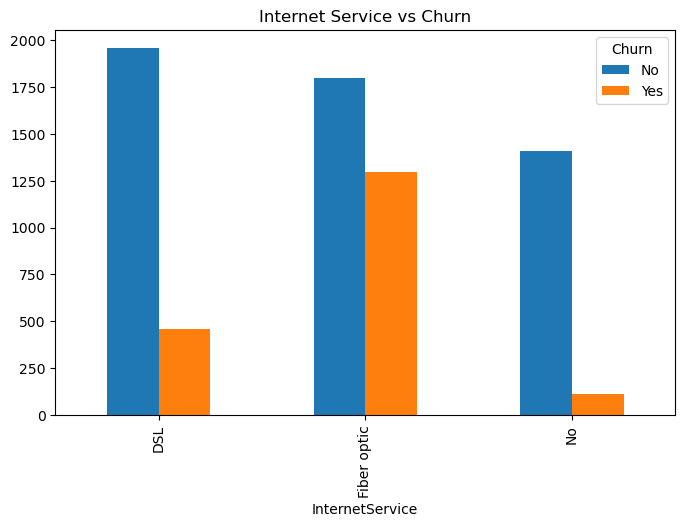

In [19]:
internet = pd.crosstab(df['InternetService'], df['Churn'])

internet.plot(kind='bar', figsize=(8,5))

plt.title("Internet Service vs Churn")

plt.show()

In [20]:
#Payment Method vs Churn
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


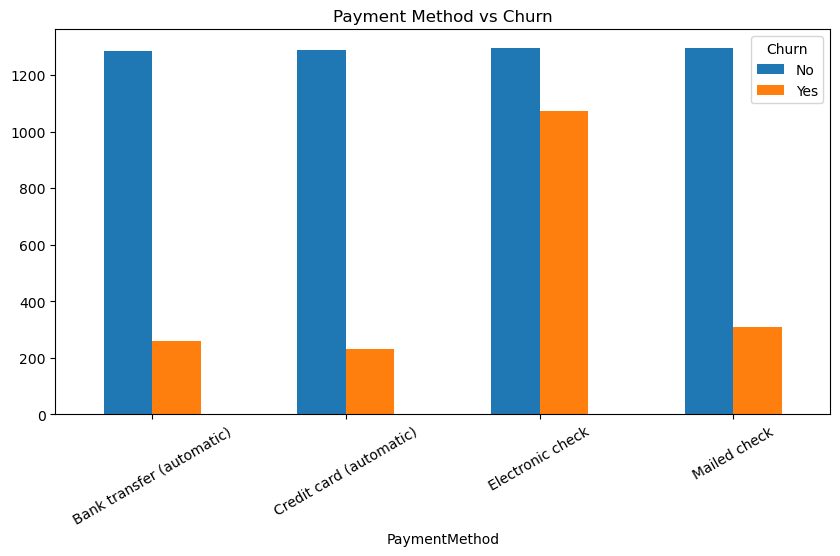

In [21]:
payment = pd.crosstab(df['PaymentMethod'], df['Churn'])

payment.plot(kind='bar', figsize=(10,5))

plt.title("Payment Method vs Churn")

plt.xticks(rotation=30)

plt.show()

In [23]:
#Senior Citizens
pd.crosstab(df['SeniorCitizen'], df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


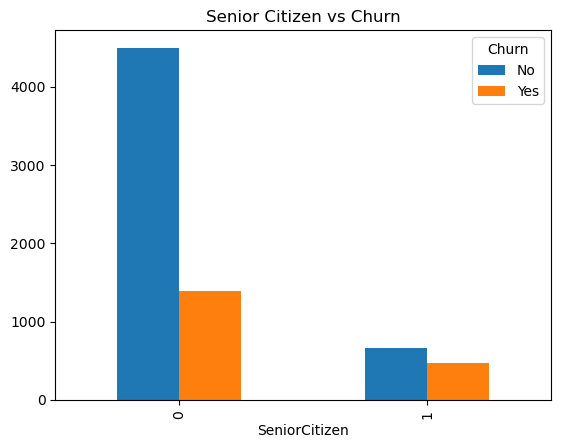

In [24]:
senior = pd.crosstab(df['SeniorCitizen'], df['Churn'])

senior.plot(kind='bar')

plt.title("Senior Citizen vs Churn")

plt.show()

In [26]:
#Partner Status
pd.crosstab(df['Partner'], df['Churn'])

Churn,No,Yes
Partner,,
No,2439,1200
Yes,2724,669


In [27]:
#Dependents
pd.crosstab(df['Dependents'], df['Churn'])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1773,326


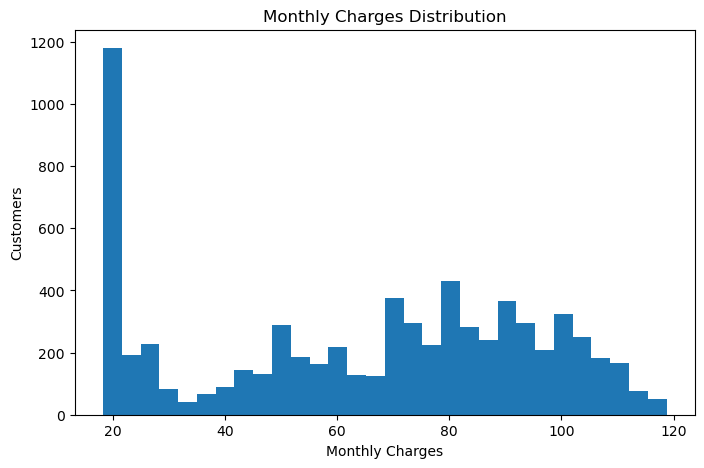

In [28]:
#Monthly Charges Distribution
plt.figure(figsize=(8,5))

plt.hist(df['MonthlyCharges'], bins=30)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges")

plt.ylabel("Customers")

plt.show()

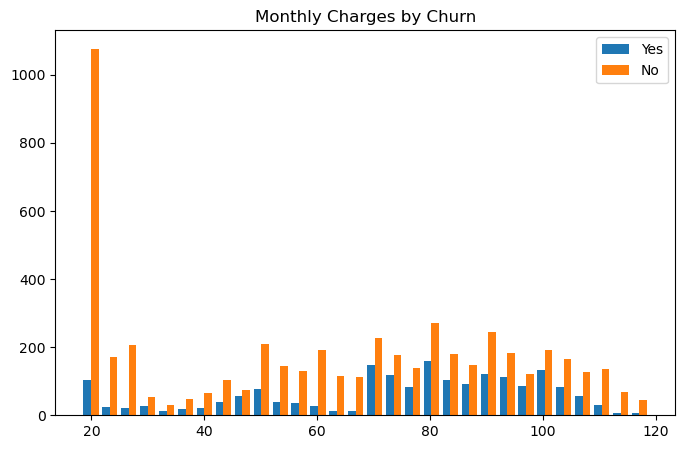

In [29]:
#Monthly Charges by Churn
yes = df[df['Churn']=="Yes"]['MonthlyCharges']
no = df[df['Churn']=="No"]['MonthlyCharges']

plt.figure(figsize=(8,5))

plt.hist([yes, no], bins=30, label=['Yes','No'])

plt.legend()

plt.title("Monthly Charges by Churn")

plt.show()

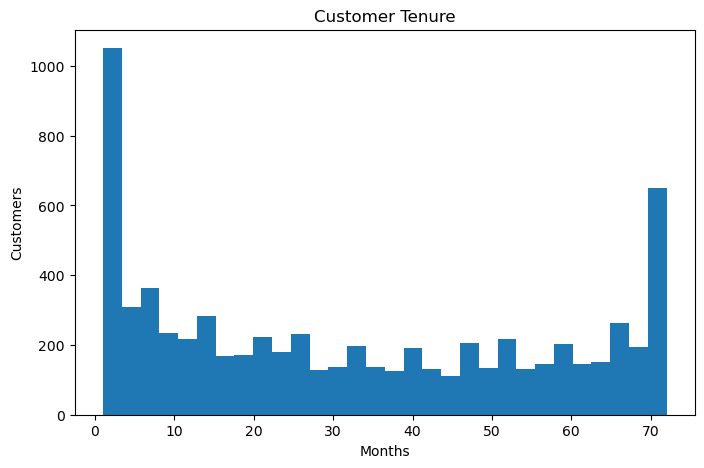

In [30]:
#Tenure Distribution
plt.figure(figsize=(8,5))

plt.hist(df['tenure'], bins=30)

plt.title("Customer Tenure")

plt.xlabel("Months")

plt.ylabel("Customers")

plt.show()

In [31]:
#Average Monthly Charge
df['MonthlyCharges'].mean()

64.79820819112628

In [32]:
#Average Tenure
df['tenure'].mean()

32.421786120591584

In [33]:
#Correlation Between Numeric Variables
numeric = df.select_dtypes(include='number')

numeric.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


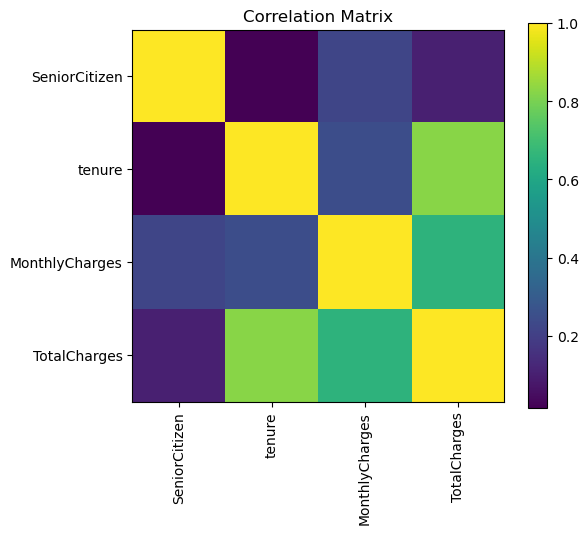

In [34]:
corr = numeric.corr()

plt.figure(figsize=(6,5))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [35]:
plt.savefig("../images/churn_distribution.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>